In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [3]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_tsk_regression import FQ_regression
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from regression.cal_house.cal_housing import CalHousing
X, y = CalHousing().get_data()

In [5]:
X.std(axis=0)

array([0.19955467, 0.22702395, 0.2468921 , 0.05557801, 0.06539025,
       0.03176044, 0.06286628, 0.13098059, 0.35502503])

In [6]:
y.std()

0.2380048790064407

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.2
batch_size=400
random_state=17
num_epochs=100
rules=20
lr=0.0005

cuda


In [10]:
train_loss = []
test_loss = []

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=random_state)
    
out_size = 1
print('out_size', out_size)
model = FQ_regression(in_features=X.shape[1],
                      rules=rules,
                      out_features=out_size,
                      device=device).to(device)

# model._rule_initialization(X_train, y_train)


X_train_eval = X_train
X_test_eval = X_test
y_train_eval = y_train
y_test_eval = y_test

X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).to(device)
y_test = torch.Tensor(y_test).to(device)


# Initialize and move model to GPU

# Initialize Adam optimizer
optimizer = optim.RMSprop(model.parameters(), lr=lr)

# Store initial parameters
initial_params = {name: param.clone().detach() for name, param in model.named_parameters()}


for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
    # for i in range(1):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        mse_loss = F.mse_loss(outputs, batch_y)
        total_loss = mse_loss  
        total_loss.backward()
        # print(model.tt.grad[0][0][0])
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test).cpu()
        mse_loss = mean_squared_error(y_test_eval, outputs, squared=False)
        total_loss = mse_loss
        test_loss.append(total_loss.item())
        #####
        outputs = model(X_train).cpu()
        mse_loss = mean_squared_error(y_train_eval, outputs, squared=False)
        total_loss = mse_loss
        train_loss.append(total_loss.item())


# train_loss = np.sqrt(train_loss)
# test_loss = np.sqrt(test_loss)

# Calculate and print the average accuracy across all folds
min_RMSE = min(test_loss)
print("minimum test RMSE:", min_RMSE)
min_RMSE = min(train_loss)
print("minimum train RMSE:", min_RMSE)

out_size 1
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([216, 10, 20])
torch.Size([10217, 10, 20])
torch.Size([10216, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20])
torch.Size([400, 10, 20

KeyboardInterrupt: 

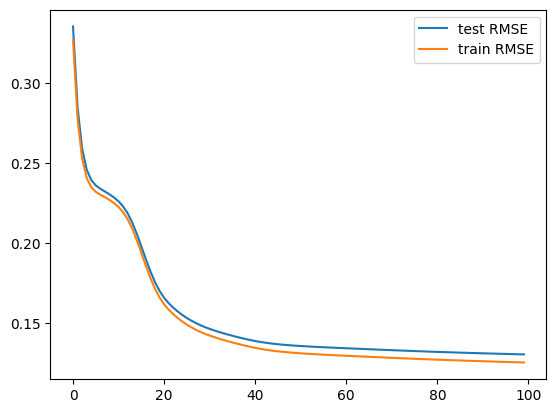

In [ ]:
plt.plot(np.arange(len(test_loss)), test_loss)
plt.plot(np.arange(len(train_loss)), train_loss)
plt.legend(['test RMSE', 'train RMSE'])
plt.show()

In [ ]:
initial_params.items()

dict_items([('mean', tensor([[[0.6199, 0.1345, 0.8189, 0.2720, 0.2601, 0.8064, 0.1601, 0.3499,
          0.7007, 0.7999],
         [0.6756, 0.5894, 0.2612, 0.1236, 0.8197, 0.3762, 0.0396, 0.6293,
          0.4643, 0.0789],
         [0.1560, 0.6511, 0.0312, 0.9049, 0.7221, 0.4713, 0.5772, 0.7626,
          0.4252, 0.8236],
         [0.9551, 0.1283, 0.2886, 0.8786, 0.7950, 0.8463, 0.2752, 0.4732,
          0.1998, 0.4733],
         [0.8156, 0.9125, 0.8661, 0.4911, 0.0998, 0.2808, 0.0873, 0.5361,
          0.3223, 0.0143],
         [0.1547, 0.7708, 0.6194, 0.9312, 0.5469, 0.2321, 0.8077, 0.7804,
          0.3904, 0.0353],
         [0.9567, 0.5598, 0.3725, 0.2986, 0.1247, 0.1316, 0.6485, 0.1651,
          0.5555, 0.6232],
         [0.4422, 0.8699, 0.8565, 0.6310, 0.5658, 0.7956, 0.0692, 0.3061,
          0.6678, 0.0899],
         [0.2599, 0.8695, 0.8088, 0.6188, 0.3354, 0.1617, 0.3520, 0.6204,
          0.4541, 0.1166]]], device='cuda:0')), ('std', tensor([[[0.0255, 0.2322, 0.7999, 0.1104,

In [ ]:
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}
updated_params

{'mean': tensor([[[ 0.6383,  0.0149,  0.4301,  0.2219,  0.3061,  1.0819,  0.1871,
            0.3354,  0.5895,  1.1624],
          [ 0.4324,  0.2340,  0.2370,  0.2838,  0.6191,  0.6484,  0.1204,
            0.3210,  0.0461, -0.0882],
          [ 0.1934,  0.8398, -0.0022,  1.0128,  0.8073,  0.4607,  0.2556,
            1.3756,  0.4537,  1.0005],
          [ 0.9587,  0.3759, -0.0538,  0.7361,  0.7381,  0.5853,  0.3809,
            0.4067,  0.1549,  0.7412],
          [ 0.8093,  0.6494,  1.1053,  0.6794,  0.1959,  0.1751,  0.2280,
            0.0869, -0.0975,  0.0381],
          [-0.1354,  0.7708,  0.3470,  0.9312,  0.5555, -0.2063,  0.5759,
            0.5013,  0.4136,  0.1504],
          [ 0.9265,  0.7888,  0.5492,  0.3329,  0.2819,  0.1174,  0.5876,
            0.5008,  0.3152,  0.2544],
          [ 0.6614,  1.3046,  1.0442,  0.7042,  0.6468,  0.8329,  0.0384,
            0.3383,  0.8522,  0.0460],
          [ 0.4262,  1.0913,  0.6260,  0.3283,  0.3194,  0.0408,  0.1570,
            0.

In [ ]:
# After training, you can get the updated parameters
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}

# # Calculate the difference between initial and updated parameters
# param_diff = {name: updated - initial for name, (updated, initial) in zip(updated_params.items(), initial_params.items())}

# Print the difference
for name, updated in updated_params.items():
    print(name)
    print(updated - initial_params[name])

mean
tensor([[[ 1.8413e-02, -1.1962e-01, -3.8890e-01, -5.0088e-02,  4.6015e-02,
           2.7552e-01,  2.7056e-02, -1.4454e-02, -1.1125e-01,  3.6252e-01],
         [-2.4324e-01, -3.5545e-01, -2.4190e-02,  1.6028e-01, -2.0058e-01,
           2.7225e-01,  8.0809e-02, -3.0834e-01, -4.1817e-01, -1.6716e-01],
         [ 3.7425e-02,  1.8870e-01, -3.3440e-02,  1.0787e-01,  8.5197e-02,
          -1.0652e-02, -3.2157e-01,  6.1296e-01,  2.8496e-02,  1.7690e-01],
         [ 3.6090e-03,  2.4756e-01, -3.4240e-01, -1.4251e-01, -5.6976e-02,
          -2.6092e-01,  1.0571e-01, -6.6508e-02, -4.4844e-02,  2.6788e-01],
         [-6.2919e-03, -2.6308e-01,  2.3918e-01,  1.8833e-01,  9.6116e-02,
          -1.0568e-01,  1.4075e-01, -4.4924e-01, -4.1973e-01,  2.3843e-02],
         [-2.9003e-01, -1.1981e-05, -2.7240e-01,  0.0000e+00,  8.5565e-03,
          -4.3842e-01, -2.3173e-01, -2.7909e-01,  2.3250e-02,  1.1517e-01],
         [-3.0259e-02,  2.2909e-01,  1.7663e-01,  3.4262e-02,  1.5722e-01,
          -1.4

In [ ]:
model.mean

Parameter containing:
tensor([[[ 0.6383,  0.0149,  0.4301,  0.2219,  0.3061,  1.0819,  0.1871,
           0.3354,  0.5895,  1.1624],
         [ 0.4324,  0.2340,  0.2370,  0.2838,  0.6191,  0.6484,  0.1204,
           0.3210,  0.0461, -0.0882],
         [ 0.1934,  0.8398, -0.0022,  1.0128,  0.8073,  0.4607,  0.2556,
           1.3756,  0.4537,  1.0005],
         [ 0.9587,  0.3759, -0.0538,  0.7361,  0.7381,  0.5853,  0.3809,
           0.4067,  0.1549,  0.7412],
         [ 0.8093,  0.6494,  1.1053,  0.6794,  0.1959,  0.1751,  0.2280,
           0.0869, -0.0975,  0.0381],
         [-0.1354,  0.7708,  0.3470,  0.9312,  0.5555, -0.2063,  0.5759,
           0.5013,  0.4136,  0.1504],
         [ 0.9265,  0.7888,  0.5492,  0.3329,  0.2819,  0.1174,  0.5876,
           0.5008,  0.3152,  0.2544],
         [ 0.6614,  1.3046,  1.0442,  0.7042,  0.6468,  0.8329,  0.0384,
           0.3383,  0.8522,  0.0460],
         [ 0.4262,  1.0913,  0.6260,  0.3283,  0.3194,  0.0408,  0.1570,
           0.6382

In [ ]:
torch.tanh(model.tt)

tensor([[[ 0.0714,  0.3768, -0.3316,  0.4090, -0.1327,  0.0706,  0.3434,
          -0.2038,  0.6362,  0.1990],
         [-0.1000, -0.3855, -0.2605,  0.3760, -0.0679,  0.6426,  0.2965,
          -0.3255,  0.2023,  0.2876],
         [ 0.1462, -0.2573,  0.4909,  0.1705,  0.0866,  0.0845, -0.1853,
           0.0747,  0.1674,  0.2791],
         [ 0.1363,  0.4703, -0.3101, -0.2090,  0.0125, -0.3069, -0.0069,
           0.5118, -0.1078,  0.1612],
         [ 0.0773, -0.2125,  0.4421,  0.0997, -0.2124, -0.2823,  0.0768,
          -0.6953, -0.1072, -0.4262],
         [-0.2464,  0.1627,  0.4991, -0.0010, -0.0421, -0.4186, -0.2069,
           0.2917, -0.1300, -0.3969],
         [ 0.0314,  0.2773,  0.5682,  0.0977, -0.0349, -0.5062,  0.0694,
           0.6653, -0.1776, -0.1634],
         [-0.4564,  0.2046,  0.0959,  0.4350, -0.4938,  0.0685, -0.3059,
           0.2044,  0.1531, -0.2608],
         [ 0.4807,  0.5033, -0.3129, -0.3714,  0.2827, -0.0705, -0.1126,
           0.1937,  0.0007, -0.0255]]],

In [ ]:
model.linear.weight

Parameter containing:
tensor([[-2.4573e-01, -2.2801e-02, -5.7630e-02,  2.5851e-01, -2.9511e-01,
          7.1187e-02,  2.9143e-01,  1.8343e-01,  3.7495e-01,  2.4642e-01,
         -2.3535e-01, -2.1802e-01, -8.1995e-03,  3.3988e-01, -1.3511e-01,
          3.9328e-02,  2.6019e-01,  1.3909e-01,  1.2115e-01,  2.8528e-01,
         -2.0519e-01, -3.3662e-02,  1.1548e-02,  2.6827e-01, -2.6893e-01,
         -1.3077e-01,  3.8236e-01,  1.1187e-01,  3.3406e-01,  4.4488e-01,
         -2.7273e-01, -1.4513e-01, -1.5372e-02,  9.4095e-02, -1.8694e-01,
          2.0942e-01,  3.1584e-01,  2.6884e-01,  1.5515e-01,  1.9490e-01,
          1.4520e-03,  2.3142e-02,  2.1012e-01,  5.2813e-01,  2.9553e-02,
          3.0059e-01,  4.8326e-01,  3.5161e-01,  4.4841e-01,  4.5286e-01,
         -7.5219e-01, -4.7119e-01, -2.9074e-01, -3.9563e-01, -8.1734e-01,
         -2.9772e-01, -5.5089e-01,  8.0918e-02, -5.0271e-01, -5.2742e-01,
         -1.1311e-01, -5.0398e-04,  5.8388e-02,  3.3851e-01, -9.0973e-02,
          2.3011

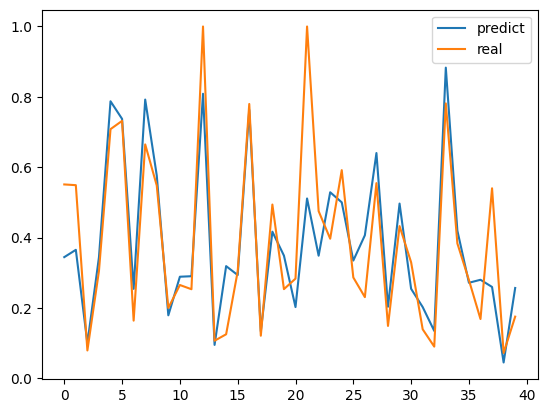

In [ ]:
model.eval()
with torch.no_grad():
    plt.plot(np.array(model(X_test).to('cpu'))[40:80])
    plt.plot(y_test.cpu()[40:80])
    plt.legend(['predict', 'real'])

In [ ]:
np.sqrt(mean_squared_error(np.array(model(X_test).detach().to('cpu')), y_test.cpu()))

0.13040848

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>
CAL HOUSING : tsk:0.34, mamdani=0.33